In [ ]:
"""
■ EV価格分析レポート
（AI Learner EV Dataset を用いた価格妥当性とコスパ分析）

1. 目的
欧州市場で販売されている電気自動車（EV）を対象に、性能から見た「理論価格」を推定、
実際の価格とのズレ（割高・割安）を評価とコストパフォーマンスの高い車種・低い車種を
特定することを目的とする。

2. 使用データ
Kaggleの「AI Learner Tech: EV Prices 2026」データセットを使用し、以下の情報を分析対象とした。
・価格（PriceEuro）
・航続距離（Range_Km）
・最高速度（TopSpeed_KmH）
・加速性能（AccelSec）
・電費（Efficiency_WhKm）
・ブランド（Brand）

3. 実行環境
パソコン：Windows OS
開発環境：Google Coraboratory
言語：Python
ライブラリ：Pandas、Numpy、Matplotlib、Seaborn、sklearn、lightgbm

4. 分析するデータ
データはKaggleの下記データセットを使用して分析を行った：
(https://www.kaggle.com/datasets/ailearner-researchlab/ai-learner-tech-ev-prices-and-specs-2026?select=AI_Learner_EV_Dataset_Pro.csv)

"""

In [ ]:
"""
・ライブラリの読み込み
・csvデータ読み込み
・外れ値除去
・相関関係を確認するため可視化の実行

以下実行したコードと可視化の結果

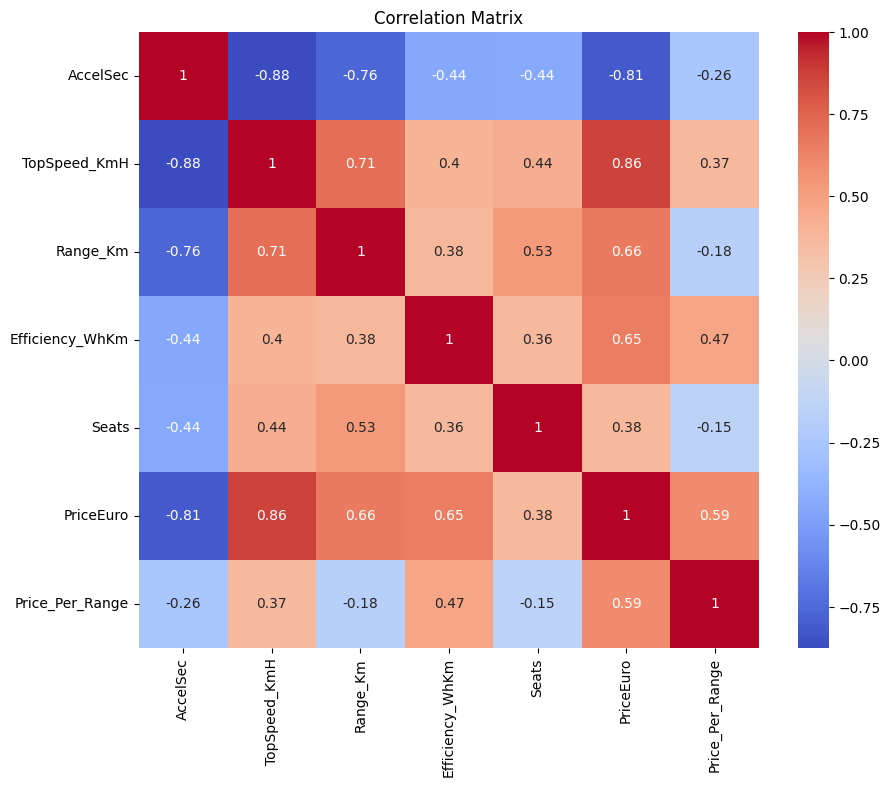

In [1]:
# =========================
# ① ライブラリ読み込み
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline

# =========================
# ② csvデータ読み込み
# =========================
dir_path = '/content/drive/MyDrive/datascience-for-beginner/archive_EV/'
df = pd.read_csv(dir_path + 'AI_Learner_EV_Dataset_Pro.csv')

# =========================
# ③ 外れ値除去（IQR）:
# 価格・速度・航続距離・加速に対してIQR（四分位範囲）を用いて外れ値を除去した。
# さらに、価格の上位1%を除外することで、極端な高級車による歪みを抑制した。
# =========================
cols = ["PriceEuro", "TopSpeed_KmH", "Range_Km", "AccelSec"]  #対象の列を指定

def remove_outliers_iqr(df, cols):  #DataFrame（df）と対象列（cols）を受け取る関数を定義
    df_clean = df.copy()  #元データを壊さないためコピーを作成
    for col in cols:
        #四分位数(データを小さい順に並べて「4つのグループ」に分けるときの区切りになる値)を計算
        Q1 = df_clean[col].quantile(0.25) #Q1（第1四分位数）：小さい順に並べたときの下から25%の位置
        Q3 = df_clean[col].quantile(0.75) #Q3（第3四分位数）：下から75%の位置
        IQR = Q3 - Q1 #IQRを計算
        #外れ値の範囲を決定:以下の範囲を外れると「外れ値」と認定する
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        #外れ値を削除:下限以上、上限以下
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean #最終結果を返す

df = remove_outliers_iqr(df, cols)

# =========================
# ④ 可視化（相関関係確認）
#1に近い → 強い正の相関
#-1に近い → 強い負の相関
# =========================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [ ]:
"""
Heatmapの表示結果からはAccelSec, TopSpeed_KmHとPriceEuroの相関性が高いように見える
TopSpeed ↔ Price → 正相関
AccelSec ↔ Price → 負相関（速いほど高い）
"""

In [ ]:
"""
特徴量エンジニアリング

以下の新たな指標を定義した：
Efficiency_Score = Range / Efficiency
　→ 電力効率（1Whあたりの走行距離）
Performance_Index = TopSpeed / AccelSec
　→ 総合的な走行性能
また、ブランドはOne-Hot Encodingにより数値化した。

人気指標（Popularity_Score）の設計

消費者がEVに求める要素として、

航続距離
電費効率
コスト効率
価格

が重要であると考え、以下の重みで統合指標を定義した：

航続距離：40%
電費効率：30%
価格効率：20%
価格：10%

この指標により、「性能＋経済性」の観点から車両の魅力度を数値化した。

以下実行したコード
"""

In [2]:
# =========================
# ⑤ 特徴量エンジニアリング
# =========================

# One-Hot Encoding前の元データを保持するためBrand_originalを保存
df["Brand_original"] = df["Brand"]

# 特徴量作成: Efficiency_ScoreとPerformance_Index
df["Efficiency_Score"] = df["Range_Km"] / df["Efficiency_WhKm"] #「1Whあたりどれだけ走れるか」を定義
df["Performance_Index"] = df["TopSpeed_KmH"] / df["AccelSec"] #「速さ × 加速性能」を定義

# =========================
# ===== 外れ値除去 =====
# 価格は歪みが強いので上位1%の超高額車を削除
# =========================
df = df[df["PriceEuro"] < df["PriceEuro"].quantile(0.99)]

# =========================
# ===== 目的変数 =====
# np.log1p():価格は分布が歪んでいるので価格の対数変換を実施
# =========================
y = np.log1p(df["PriceEuro"])

# =========================
# ===== 特徴量の定義 =====
# =========================

#One-Hotされたブランド列を自動取得
brand_cols = [col for col in df.columns if col.startswith("Brand_")]

#以下のcsvのカラムを特徴量として定義
features = [
    "Range_Km",
    "TopSpeed_KmH",
    "AccelSec",
    "Efficiency_WhKm",
    "Price_Per_Range"
] + brand_cols

#X数値だけを抽出
X = df[features].select_dtypes(include=["number"])

# =========================
# 分析するときのスコアを「Popularity_Score」としてそれぞれに重み付けを行う
# AIで「欧州消費者がEV車に求めるもの」と検索すると1回の充電で走行できる総距離距離、キロあたりの効率性、価格などとなっているので
# 以下の項目をPopularity_scoreとして重み付けをした。但し価格と性能は比例すると推測されるので価格が安いほどスコアが高くなるように正規化した。
# =========================
df["Popularity_Score"] = (
    0.40 * (df["Range_Km"] / df["Range_Km"].max()) +     # 航続距離 40%　「長いほど良い」をそのまま0～1にスコア化
    0.30 * (df["Efficiency_WhKm"].min() / df["Efficiency_WhKm"]) +  # 電力の効率性 30%　Wh/km は「小さいほど良い」にスコア化
    0.20 * (df["Price_Per_Range"].min() / df["Price_Per_Range"]) +  # キロ当たりの効率性 20%　「1kmあたり安いほど良い」にスコア化
    0.10 * ((df["PriceEuro"].max() - df["PriceEuro"]) / (df["PriceEuro"].max() - df["PriceEuro"].min())) #価格が安いほどスコアが高くなるように、0〜1に正規化している
)

# =========================
# ⑦ 特徴量再定義
# =========================

#新しく作った特徴量を採用
features = [
    "Range_Km",
    "TopSpeed_KmH",
    "AccelSec",
    "Efficiency_WhKm",
    "Performance_Index",
    "Efficiency_Score"
] + brand_cols

X = df[features].select_dtypes(include=["number"])
y = np.log1p(df["PriceEuro"]) #目的変数（y）


# =========================
# ⑧ モデルが学びやすくするために標準化（SVR用）を実施
#SVR（サポートベクター回帰）用にデータのスケールを揃える処理
#できるだけ誤差を小さくしつつ、シンプルな関数で予測する回帰モデル
# =========================
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

model = Ridge(alpha=1.0) #線形回帰 + 正則化=>過学習を防ぐ効果を期待
model.fit(X_train, y_train)

#予測と評価
pred = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, pred))

print("Final RMSE:", rmse) #ここでのRMSEはlogスケールの誤差

Final RMSE: 0.11740463024777975


In [ ]:
"""
モデル構築

以下の3モデルを比較した：

・Ridge回帰
・SVR
・LightGBM

5-fold Cross Validationにより評価した結果：

・Ridge：RMSE = 0.1288（最良）
・SVR：RMSE = 0.1525
・LightGBM：RMSE = 0.1918

よって、最も精度の高い(RMSE(誤差)が最も低い)Ridge回帰を採用した

以下実行したコード

In [3]:
# =========================
# ⑨どのモデルが最適かを確認するために
# Ridge, SVRとLightGBMを比較してRMSEを評価
# =========================
models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),

    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10))
    ]),

    "LightGBM": LGBMRegressor(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )
}

# Cros Validation評価
print("=== Cross Validation ===")

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )

    print(f"{name} RMSE: {-scores.mean():.6f}")

=== Cross Validation ===
Ridge RMSE: 0.128771
SVR RMSE: 0.152451
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000433 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 122
[LightGBM] [Info] Number of data points in the train set: 72, number of used features: 6
[LightGBM] [Info] Start training from score 10.657964
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [ ]:
"""
⑩ ベストな学習のモデルとしてRidgeを選んだが、このモデルが本当に使えるか最終確認

以下実行したコード

In [4]:
#データを 学習用80% / 検証用20% に分ける
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
#モデル学習
model = Ridge(alpha=1.0)
model.fit(X_train, y_train) #特徴量 → 価格（log） の関係を学習
#予測
pred = model.predict(X_valid)
#RMSE評価
rmse = np.sqrt(mean_squared_error(y_valid, pred))

print("\nFinal RMSE:", rmse)


Final RMSE: 0.11741056421679735


In [ ]:
"""
評価の結果から最適な学習モデルとして選定したRidgeのCross ValidationでのRMSE:0.128771と
最終確認でのRMSE:0.11741056421679735を比較して近い値であるためモデル選定が正しいと判断
"""

In [ ]:
"""
・論理価格の算出
・コスパ指標の算出
・残差の算出
・コスパ最強 TOP10、割高 Top10
・Residual別ランキングの割高、格安Top 10

以下実行したコード
"""

In [5]:
# =========================
# ⑪ 全データで価格予測：全ての車の「理論価格(性能から見て妥当な価格)」を算出
# =========================
df["PredictedPrice"] = np.expm1(model.predict(X))

# =========================
# ⑫ コスパ指標
#高い → 人気の割に安い（お得感がある）
#低い → 人気の割に高い（イマイチ）
# =========================
df["Value_Score"] = df["Popularity_Score"] / df["PredictedPrice"] #人気/価格

# =========================
# ⑬ 結果表示
# =========================

# Residual(残差)を作る：「実際の価格 − 理論価格」
df["Residual"] = df["PriceEuro"] - df["PredictedPrice"]

#結果に表示されるカラムを定義：
result = df[[
    "Brand_original",
    "Model",
    "PriceEuro",
    "PredictedPrice",
    "Range_Km",
    "Price_Per_Range",
    "Residual"   # 残差
]].sort_values("Residual")

print("\n=== コスパ最強 TOP10（割安） ===")
print(result.head(10))

print("\n=== 割高ワースト10 ===")
print(result.tail(10))

# =========================
# 追加してResidual別ランキング:割高、格安Top 10
# =========================
print("\n=== Residual(「実際の価格 − モデルが予測した価格」の差)が大きい（割高側）TOP10 ===")
print(df.sort_values("Residual", ascending=False).head(10)) #Residualが大きい=>最も割高

print("\n=== Residual(「実際の価格 − モデルが予測した価格」の差)が小さい（割安側）TOP10 ===")
print(df.sort_values("Residual", ascending=True).head(10)) #Residualが小さい=>最もお得


=== コスパ最強 TOP10（割安） ===
   Brand_original                            Model  PriceEuro  PredictedPrice  \
1          Tesla             Cybertruck Dual Motor      55000    82649.224302   
94         Tesla           Cybertruck Single Motor      45000    66414.537056   
70         Tesla    Model Y Long Range Performance      65620    75331.750035   
28      Mercedes                              EQA       45000    53969.086862   
27         Byton                 M-Byte 95 kWh 4WD      64000    72029.750290   
32        Nissan   Ariya e-4ORCE 87kWh Performance      65000    72439.067265   
10            MG                             ZS EV      30000    37368.413070   
9          Tesla     Model 3 Long Range Dual Motor      55480    62720.222193   
20        Nissan               Ariya e-4ORCE 63kWh      50000    55774.645466   
96          Opel                          Corsa-e       29146    34319.073537   

    Range_Km  Price_Per_Range      Residual  
1        460           119.57 -27649.

In [ ]:
"""
#結果の可視化①：Residual × ブランド　[ブランドごとのResidual]
#箱の中心（中央値） → そのブランドの傾向
#箱の広さ → バラつき（価格戦略の一貫性）

以下実行したコード
"""

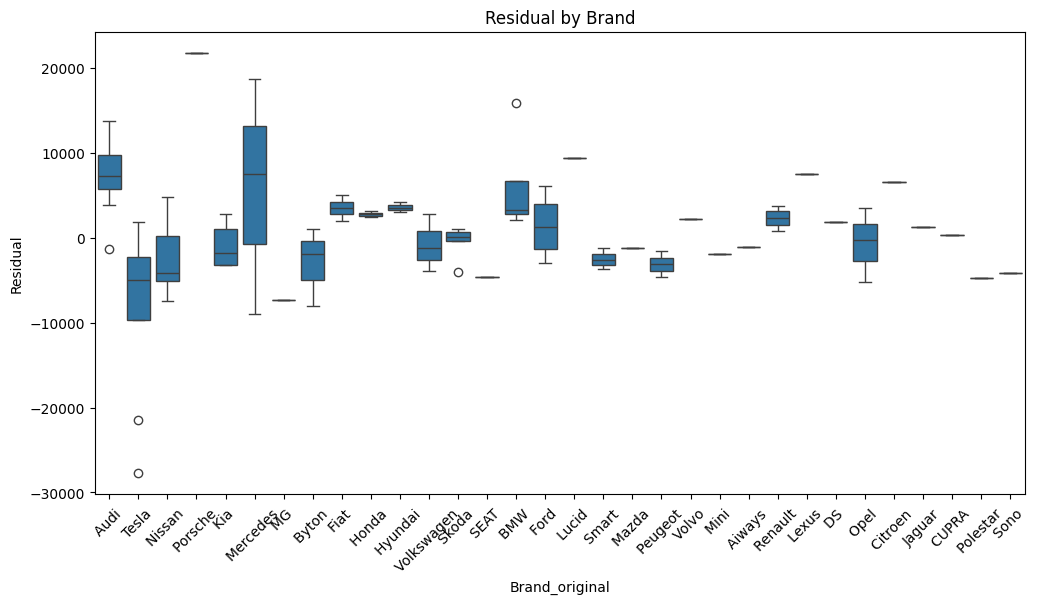

In [6]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Brand_original", y="Residual", data=df)

plt.xticks(rotation=45)
plt.title("Residual by Brand")
plt.show()

In [ ]:
"""
箱ひげ図の表示結果から中央値がプラス(割高傾向)のブランド：
・Audi
・Porsche
・Mercedes
・BMW　など
と中央値がマイナス(割安傾向)のブランドに分かれている
・Tesla
・Hyundai
・Volkswagen
・Smart
・Mazda など…

このことから高価格傾向のあるブランドは性能以上に高価格であり、ネームバリューの
上乗せが追加されている可能性が考えられる。

一方低価格傾向のブランドは性能の割に安いと考えることができ、コスパを重視したと考えられる。
"""

In [ ]:
"""
#結果の可視化②:Residual X Range　[Residualと走行距離]
#横軸：Range_Km（航続距離）
#縦軸：Residual（実価格 − 予測価格）
#赤線：Residual = 0（理論価格ライン
#上（＋） → 割高
#下（−） → 割安

以下実行したコード
"""

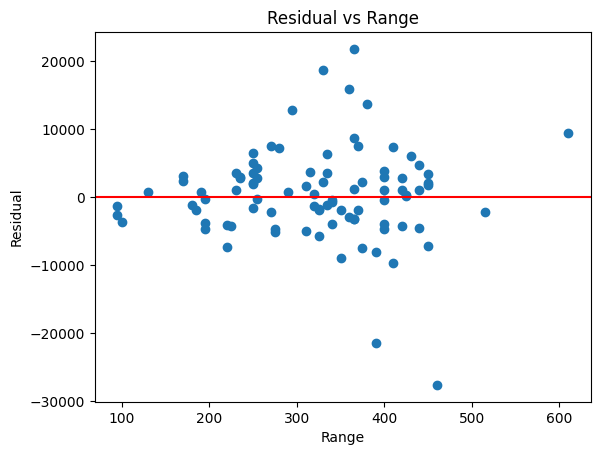

In [7]:
plt.scatter(df["Range_Km"], df["Residual"])
plt.axhline(0, color='red')

plt.xlabel("Range")
plt.ylabel("Residual")
plt.title("Residual vs Range")
plt.show()

In [ ]:
"""
可視化の結果から航続距離が長いほど価格のバラつきが大きい且つ割高・割安が混在いている。
従って航続距離だけでは価格は決まらないと考えられる。
"""

In [ ]:
"""
#結果の可視化③: Residual × Price_Per_Range（１Kmあたりのコスパ）
#横軸：Price_Per_Range（1kmあたりの価格）
#縦軸：Residual（実価格 − 予測価格）
#赤線：0（理論価格
#高いほど（kmあたり高い） → 割高
#低いほど → 割安
"""

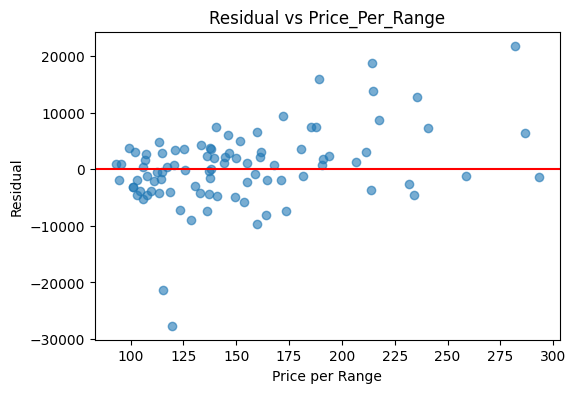

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(df["Price_Per_Range"], df["Residual"], alpha=0.6)

plt.axhline(0, color='red')

plt.xlabel("Price per Range")
plt.ylabel("Residual")
plt.title("Residual vs Price_Per_Range")
plt.show()

In [ ]:
"""
可視化の結果からグラフの右に行くほど（Price_Per_Range↑）Residualが上がる傾向がある、
従って1kmあたりのコスパが高い車ほど「割高」になりやすい傾向があることが分かる。
また、グラフの左側に行くほど（Price_Per_Range↓)Residualが下がる傾向がある、
従って割安な車が集中している。
"""

In [ ]:
"""
#結果の可視化④: Residual × PriceEuro（価格）
#価格に対して予測誤差（Residual）がどう分布しているか
#X軸：価格
#Y軸：誤差
#赤線：誤差ゼロのライン
"""

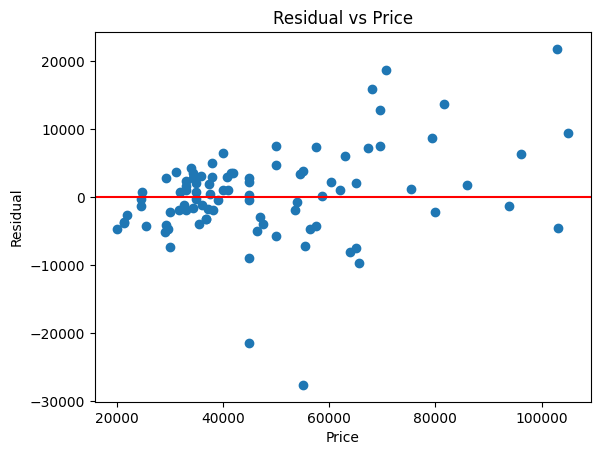

In [9]:
plt.scatter(df["PriceEuro"], df["Residual"])
plt.axhline(0, color='red')

plt.xlabel("Price")
plt.ylabel("Residual")
plt.title("Residual vs Price")
plt.show()

In [ ]:
"""
可視化の結果から低価格帯（左側）は点の分布にばらつきが少ない、
一方高価格帯（右側）はばらつきが大きいので高価格帯は予測が不安定
"""

In [ ]:
"""
#結果の可視化⑤:Residual X Range　[航続距離（Range）と価格のズレ（コスパ）]
#0より上（＋） → 割高
#0より下（−） → 割安
"""

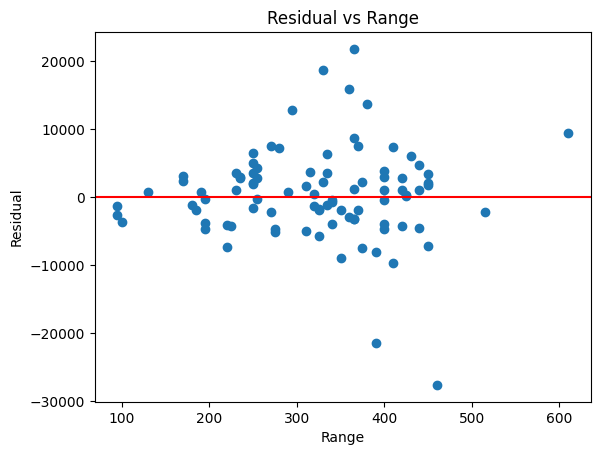

In [10]:
plt.scatter(df["Range_Km"], df["Residual"])
plt.axhline(0, color='red')

plt.xlabel("Range")
plt.ylabel("Residual")
plt.title("Residual vs Range")
plt.show()

In [ ]:
"""
可視化の結果から全体的に0のラインの周りに散らばってるので大きな偏りはないと考える。
300〜400kmあたりバラつきが大きいので同じ航続距離でも価格差が大きい。
長距離（400km以上）上にも下にも大きくズレている、高性能帯は「割高・割安」が混在。
"""

In [ ]:
"""
#結果の可視化⑥:Actual vs Predicted　[「実際の価格」と「予測価格」がどれだけ一致しているか確認]
#横軸（X）：実際の価格 PriceEuro
#縦軸（Y）：予測価格 PredictedPrice
"""

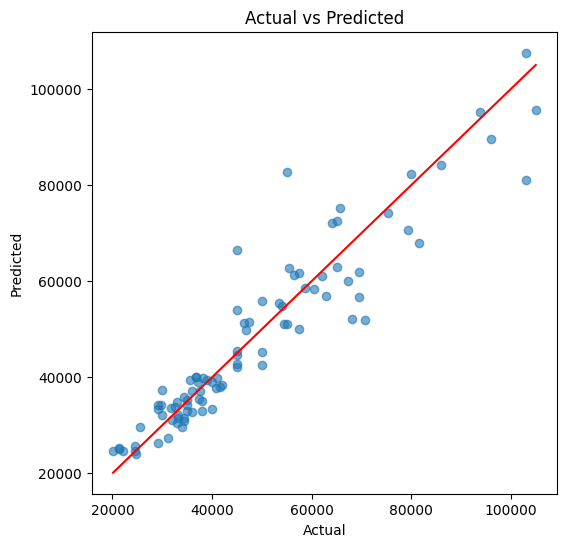

In [12]:
plt.figure(figsize=(6,6))
plt.scatter(df["PriceEuro"], df["PredictedPrice"], alpha=0.6)

plt.plot(
    [df["PriceEuro"].min(), df["PriceEuro"].max()],
        [df["PriceEuro"].min(), df["PriceEuro"].max()],
            color='red'
            )

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [ ]:
"""
可視化の結果から実際の販売価格が低いものは予測価格との誤差が少なく、実際の販売価格が高いものは
誤差が大きいので高価格帯での実際の幅い価格と予測にばらつきがある。
ばらつきの可能性として特定の高価格帯のブランドでは独自のネームバリューが付加されている可能性が考えられる。
"""

In [ ]:
"""
まとめ：
Heatmapで相関関係を確認したところ価格(PriceEuro)とAccelSec, TopSpeed_KmHとの強い相関関係があると思われ
価格はAccelSec, TopSpeed_KmHに比例しているように推測される。
一方で一般的に消費者が求める項目としては1回の充電で走行できる総距離距離、キロあたりの効率性、価格など
そのため特徴量として：
    "Range_Km",
    "TopSpeed_KmH",
    "AccelSec",
    "Efficiency_WhKm",
    "Price_Per_Range"
を採用した。
また分析時の「重み付け」として対象の項目に下記の割合を付与した：
     航続距離 40%：　「長いほど良い」をそのまま0～1にスコア化
     電力の効率性 30%：　Wh/km は「小さいほど良い」にスコア化
     キロ当たりの効率性 20%：　「1kmあたり安いほど良い」にスコア化
     価格 10%：　　　  価格が安いほどスコアが高くなるように、0〜1に正規化している

どのモデルを使用して学習させるか決めるためにLightGBM, SVRとRidgeの誤差を算出させ
誤差(RMSE)の最も少ないRidgeを使用することにした。

学習の結果から以下の2点について考察した結果をもとにTop 10を割り出した：
①コスパ最強Top 10と割高Top 10
②Residual別のTop, Worst 10


追加して次の観点での可視化も実施した：
①Residual × ブランド　[ブランドごとのResidual]
分かったこととして高価格帯のブランドと低価格帯のブランドがあることがわかった。
高価格帯のブランドは推測としてブランドのネームバリューが付加される可能性がある。
低価格帯のブランドは機能の割には安価なモデルを揃えているように見える。

②Residual × Range　[Residualと走行距離]
可視化の結果から分かったこととして、航続距離が長いほど価格のバラつきが大きい
且つ割高・割安が混在いている。そのため「航続距離が長い＝高価格」の関係はではない。

③Residual × Price_Per_Range  [1Kmあたりのコスパ]
可視化の結果から分かったこととして、1kmあたりのコスパが高い車ほどResidualも高止まりするため
それら車種は「割高」になりやすい傾向がある。

④Residual × PriceEuro  [価格]
可視化の結果から分かったこととして、低価格帯分布にばらつきが少ない。
一方高価格帯はばらつきが大きい。従って高価格帯は予測が不安定と思われる。

⑤Residual × Range　[航続距離（Range）と価格のズレ（コスパ）]
可視化の結果から分かったこととして、全体0のラインの周りに散らばってるので大きな偏りはない。
航続距離300〜400kmあたりバラつきが大きいので同じ航続距離でも価格差が大きい。
長距離（400km以上）ではResidualが上方向にも下方向にも大きくズレている、高性能帯は「割高・割安」が混在。

⑥Actual × Predicted　[「実際の価格」と「予測価格」がどれだけ一致しているか確認]
可視化の結果から分かったこととして、実際の販売価格が低いものは予測価格との誤差が少ない。
実際の販売価格が高いものは誤差が大きいので高価格帯での実際の幅い価格と予測にばらつきがある。


総合考察
本分析から以下の知見が得られた：

① EV価格は性能だけでは決まらない
→ 特に高価格帯ではブランド価値の影響が大きい

② コスパの良い車は特定メーカーに集中
→ Teslaや一部大衆ブランドは価格戦略が競争的

③ 航続距離は重要だが決定要因ではない
→ 同距離でも価格差が大きい

④ 高価格帯ほど市場価格と理論価格の乖離が大きい
→ プレミアム要素が価格に上乗せされている


結論
機械学習を用いてEV車の「理論価格」を推定し、市場価格との比較により
コストパフォーマンスを評価した。

その結果、EV価格は性能だけでなくブランド価値によって大きく左右されることが明らかとなった。
"""